In [6]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [8]:
len(x_train), len(x_test)

(60000, 10000)

In [12]:
x_train.shape

(60000, 28, 28)

In [69]:
x_train=x_train / 255.0
x_test=x_test / 255.0

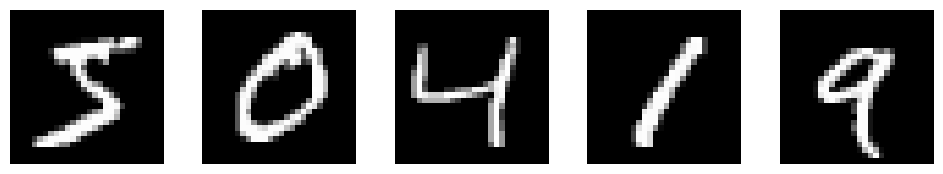

In [70]:
fig, axes = plt.subplots(1, 5, figsize=(12, 2))
for i in range(5):
    axes[i].imshow(x_train[i], cmap='gray')
    axes[i].axis('off')
plt.show()

In [71]:
y_train[:5]  

array([5, 0, 4, 1, 9], dtype=uint8)

In [72]:
x_train_flat = x_train.reshape(len(x_train),28*28)
x_test_flat = x_test.reshape(len(x_test),28*28)
x_train_flat.shape

(60000, 784)

In [74]:
x_train_flat[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [75]:
model = keras.Sequential([
    keras.layers.Input(shape=(28*28,)),
    keras.layers.Dense(10, activation='sigmoid')
])

In [76]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [77]:
model.fit(x_train_flat, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 838us/step - accuracy: 0.8781 - loss: 0.4682
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 809us/step - accuracy: 0.9147 - loss: 0.3037
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - accuracy: 0.9209 - loss: 0.2833
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - accuracy: 0.9237 - loss: 0.2729
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 833us/step - accuracy: 0.9255 - loss: 0.2667


In [78]:
model.evaluate(x_test_flat, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 784us/step - accuracy: 0.9259 - loss: 0.2680


[0.26796820759773254, 0.9258999824523926]

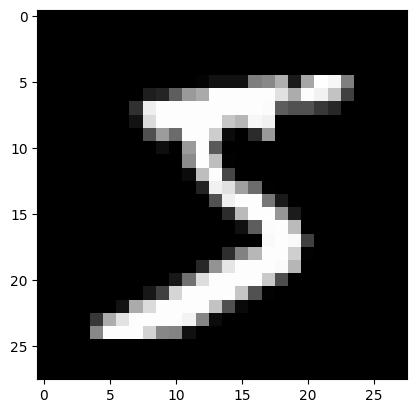

In [79]:
plt.imshow(x_train[0], cmap='gray')

In [89]:
y_predicted_0 = model.predict(x_test_flat[0:1])
y_predicted_0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


array([[2.1276545e-02, 1.8798613e-07, 4.1170478e-02, 9.4179285e-01,
        1.8772081e-03, 8.0883995e-02, 1.0356043e-06, 9.9964494e-01,
        8.3843276e-02, 5.0895727e-01]], dtype=float32)

In [90]:
np.argmax(y_predicted_0)

np.int64(7)

In [91]:
y_predicted = model.predict(x_test_flat)
y_predicted_labels = [np.argmax(i) for i in y_predicted]
y_predicted_labels[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step


[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [92]:
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 966,    0,    1,    2,    0,    5,    3,    2,    1,    0],
       [   0, 1112,    3,    2,    0,    1,    4,    2,   11,    0],
       [   4,   10,  928,   17,    8,    3,   11,    9,   39,    3],
       [   3,    0,   22,  925,    1,   20,    2,    8,   22,    7],
       [   1,    1,    6,    2,  920,    0,    7,    3,   11,   31],
       [  10,    2,    6,   38,   11,  765,    9,    5,   39,    7],
       [  14,    3,   11,    1,    8,   15,  900,    2,    4,    0],
       [   1,    5,   23,    8,   10,    1,    0,  944,    3,   33],
       [   6,    7,    7,   20,    9,   20,    7,   10,  882,    6],
       [  11,    7,    1,   13,   32,    5,    0,   14,    9,  917]],
      dtype=int32)>

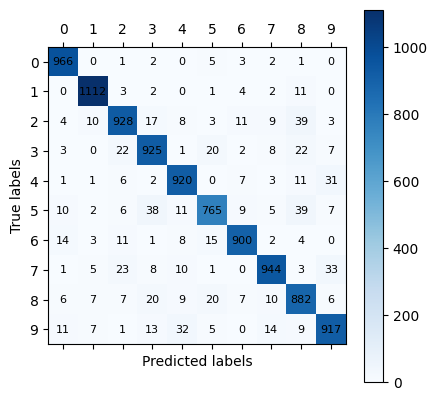

In [95]:
pyplot = plt.matshow(cm, cmap=plt.cm.Blues)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.xticks(range(10))
plt.yticks(range(10))
plt.colorbar()

# Add text annotations
for i in range(10):
    for j in range(10):
        plt.text(j, i, str(cm[i, j].numpy()), ha='center', va='center', color='black', fontsize=8)